In [1]:
#| default_exp _trainer

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
#| export
import torch
import matplotlib.pyplot as plt
from dreamer4._core import build_tiny_pinpad_dataset, make_tiny_dataloader
from dreamer4.dreamer4 import VideoTokenizer, DynamicsWorldModel
from dreamer4.trainers import VideoTokenizerTrainer, SimTrainer, cycle, BehaviorCloneTrainer

/home/j/workspace/dreamer4/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
CPU = False
neps = 20
device = 'cuda' if not CPU else 'cpu'
dataset, env = build_tiny_pinpad_dataset(device=device, episode_length=100, n=neps)

pads {'3', '1', '2'} target ('1', '2', '3')

Built tiny PinPad dataset with 20 videos of shape torch.Size([3, 100, 64, 64]) - (c, t, h, w). Success rate 85.0%


In [5]:
import random
from typing import Optional, Literal, Dict, Any, List
from dreamer4.envs.pinpad import PinPad, MotionPlannerPinPad

import torch
from torch.utils.data import Dataset, TensorDataset

class NormalizeObsWrapper:
    """
    Wraps a PinPad env that returns (C,H,W) uint8/float in 0..255 and
    converts observations to float32 in [0,1]. Everything else is passthrough.
    """
    def __init__(self, env):
        self.env = env
        # expose gym-ish interface
        self.action_space = env.action_space
        self.observation_space = getattr(env, "observation_space", None)
        self.device = getattr(env, "device", "cpu")
        self.size = getattr(env, "size", (64, 64))
        self.task = getattr(env, "task", "three")

    def _norm(self, obs):
        # obs is a torch.Tensor (C,H,W) from your PinPad
        obs = obs.to(torch.float32)
        # If it looks like 0..255, scale to 0..1. Otherwise assume already normalized.
        if obs.max() > 1.0 or obs.min() < 0.0:
            obs = obs / 255.0
        return obs

    def reset(self, *args, **kwargs):
        obs = self.env.reset(*args, **kwargs)
        return self._norm(obs)

    def step(self, action):
        obs, r, done, truncated, info = self.env.step(action)
        return self._norm(obs), r, done, truncated, info

    # Optional: pass through render() etc.
    def render(self, *args, **kwargs):
        return self.env.render(*args, **kwargs)

class PinPadBCEpisodes(Dataset):
    def __init__(self, env, n_episodes=512, episode_length=16, use_motion_planner=True):
        self.samples = []
        H, W = env.size[0], env.size[1]

        if use_motion_planner:
            mp = MotionPlannerPinPad(env)

        for _ in range(n_episodes):
            frames = []
            rewards = []
            actions = []

            obs = env.reset()                  # (C, H, W) float in 0..255
            for t in range(episode_length):
                frames.append(obs)              # store frame BEFORE action (standard)

                if use_motion_planner:
                    act = mp.sample()
                else:
                    act = env.action_space.sample()

                obs, r, done, _, _ = env.step(act)

                rewards.append(float(r))        # scalar
                actions.append(int(act))        # scalar int

                if done:                        # keep fixed length anyway
                    # pad the remainder by repeating last frame / zeros reward / no-op
                    for _pad in range(t + 1, episode_length):
                        frames.append(obs)
                        rewards.append(0.0)
                        actions.append(0)
                    break

            # Stack & reshape
            # frames: list of (C,H,W) -> (T,C,H,W) -> (C,T,H,W), normalize to [0,1]
            frames = torch.stack(frames, dim=0).float()
            frames = frames.permute(1, 0, 2, 3).contiguous()      # (C,T,H,W)

            rewards = torch.tensor(rewards, dtype=torch.float32)  # (T,)
            discrete = torch.tensor(actions, dtype=torch.long).unsqueeze(-1)  # (T,1)

            # sanity
            assert frames.shape[1] == episode_length
            assert rewards.shape[0] == episode_length
            assert discrete.shape[:2] == (episode_length, 1)

            self.samples.append({
                "video": frames,                # (C,T,H,W) float[0,1]
                "rewards": rewards,             # (T,)
                "discrete_actions": discrete,   # (T,1)
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

def build_pinpad_datasets_for_trainers(
    n_tok_episodes=512,
    n_bc_episodes=512,
    episode_length=16,
    device="cuda",
    use_motion_planner=True,
    normalize_in_env=True,   # <— new
):
    # base env
    base_env = PinPad('three', length=episode_length, extra_obs=False,
                      size=[64, 64], random_starting_pos=True, device=device)
    env = NormalizeObsWrapper(base_env) if normalize_in_env else base_env

    # ---- tokenizer dataset (VideoTokenizerTrainer still expects TensorDataset)
    vids = []
    mp_tok = MotionPlannerPinPad(env) if use_motion_planner else None
    for _ in range(n_tok_episodes):
        frames = []
        obs = env.reset()
        for t in range(episode_length):
            frames.append(obs)  # (C,H,W) already 0..1 if normalize_in_env
            act = mp_tok.sample() if mp_tok else env.action_space.sample()
            obs, r, done, _, _ = env.step(act)
            if done:
                for _pad in range(t + 1, episode_length):
                    frames.append(obs)
                break

        frames = torch.stack(frames, dim=1).contiguous()  # (C,T,H,W)
        if not normalize_in_env:
            frames = frames.float() / 255.0

        vids.append(frames)

    tok_videos = torch.stack(vids, dim=0)  # (N,C,T,H,W)
    tok_ds = TensorDataset(tok_videos)

    # ---- BC dataset (BehaviorCloneTrainer expects dict -> model(**batch))
    # Separate env so RNG/state differs a bit
    base_env_bc = PinPad('three', length=episode_length, extra_obs=False,
                         size=[64, 64], random_starting_pos=True, device=device)
    env_bc = NormalizeObsWrapper(base_env_bc) if normalize_in_env else base_env_bc
    bc_ds = PinPadBCEpisodes(env_bc, n_episodes=n_bc_episodes,
                             episode_length=episode_length,
                             use_motion_planner=use_motion_planner)

    return tok_ds, bc_ds, env

# 1) Build datasets
tok_ds, bc_ds, env = build_pinpad_datasets_for_trainers(
    n_tok_episodes=512,
    n_bc_episodes=512,
    episode_length=16,
    device='cuda',
    use_motion_planner=True
)


pads {'3', '1', '2'} target ('1', '2', '3')

pads {'3', '1', '2'} target ('1', '2', '3')



tok_ds[0] raw: torch.Size([3, 16, 64, 64]) torch.float32 min/max: 0.0 1.0
tok_ds[0] canonical: torch.Size([3, 16, 64, 64]) torch.float32 min/max: 0.0 1.0


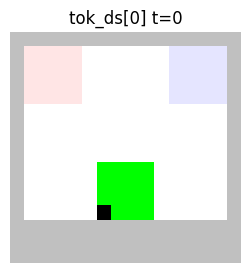

bc_ds[0] raw: torch.Size([3, 16, 64, 64]) torch.float32 min/max: 0.0 1.0
bc_ds[0] canonical: torch.Size([3, 16, 64, 64]) torch.float32 min/max: 0.0 1.0


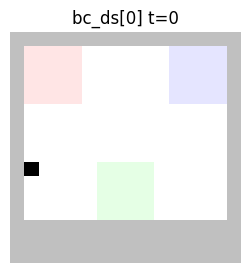

In [6]:
import torch
import matplotlib.pyplot as plt

def get_video_from_sample(sample):
    """Return a (C,T,H,W) or (T,C,H,W) tensor from dict/tuple/tensor samples."""
    if isinstance(sample, dict):
        v = sample.get("video", next((x for x in sample.values() if torch.is_tensor(x)), None))
    elif isinstance(sample, (list, tuple)):
        # common case: TensorDataset(videos) -> (video,)
        v = sample[0]
    else:
        v = sample
    if not torch.is_tensor(v):
        raise TypeError(f"Couldn't find a tensor video in sample of type {type(sample)}")
    return v

def canonicalize_cthw(v):
    """Ensure (C,T,H,W); convert dtype/range for visibility."""
    if v.ndim != 4:
        raise ValueError(f"Expected 4D video, got shape {tuple(v.shape)}")
    # If first dim isn't channels, assume (T,C,H,W) and permute
    if v.shape[0] not in (1,3):
        v = v.permute(1,0,2,3).contiguous()  # (T,C,H,W) -> (C,T,H,W)
    # Make float in [0,1] for viewing
    if v.dtype.is_floating_point:
        # if it looks zero-centered, de-normalize (heuristic)
        if v.min() < 0:
            v = (v * 0.5) + 0.5
        v = v.clamp(0,1)
    else:
        v = v.float() / 255.0
    return v

def peek_video(sample, title="sample", t=0):
    v = get_video_from_sample(sample)
    print(f"{title} raw:", v.shape, v.dtype, "min/max:", float(v.min()), float(v.max()))
    v = canonicalize_cthw(v)
    C,T,H,W = v.shape
    img = v[:, min(t,T-1)].permute(1,2,0).cpu().numpy()
    print(f"{title} canonical:", v.shape, v.dtype, "min/max:", float(v.min()), float(v.max()))
    plt.figure(figsize=(3,3)); plt.imshow(img); plt.title(f"{title} t={min(t,T-1)}"); plt.axis("off"); plt.show()
    return v

# Use on both datasets:
v_tok = peek_video(tok_ds[0], title="tok_ds[0]")
v_bc  = peek_video(bc_ds[0],  title="bc_ds[0]")


In [7]:
lpips_loss = 0.05
dim, dim_latent = 64, 64
tk = VideoTokenizer(
    dim=dim,#16,
    # encoder_depth = 1, # I think the paper has a different depths and does the time blocks every n (8?) layers
    # decoder_depth = 1,
    # time_block_every = 1,
    dim_latent = dim_latent, #16,
    patch_size = 16, #32
    attn_dim_head = 16,
    num_latent_tokens = 4,
    lpips_loss_weight=lpips_loss,
).to(device)

dynamics = DynamicsWorldModel(
    video_tokenizer = tk,
    dim = dim, #16,
    dim_latent = dim_latent, #16,
    max_steps = 64,
    num_tasks = 1,
    num_latent_tokens = 4, #1,
    # depth = 1,
    # time_block_every = 1,
    # num_spatial_tokens = 1,
    pred_orig_latent = True,
    num_discrete_actions = env.action_space.n,
    attn_dim_head = 16,
    prob_no_shortcut_train = 0.1,
    num_residual_streams = 1
).to(device)

In [8]:


# 2) Train tokenizer (VideoTokenizerTrainer expects a TensorDataset and uses [0])
tok_tr = VideoTokenizerTrainer(tk, tok_ds, batch_size=16, num_train_steps=100)
tok_tr()

# 3) Train world model with BC (BehaviorCloneTrainer expects a dict batch and calls model(**batch))
bc_tr = BehaviorCloneTrainer(dynamics, bc_ds, batch_size=16, num_train_steps=100)
bc_tr()


# 4) Evaluate / roll out as before (SimTrainer / eval_episodes, etc.)


WM trained for 99 steps. mean loss 0.30610232196748255
training complete


In [9]:
import torch
import torch.nn.functional as F
from einops import rearrange

@torch.no_grad()
def eval_next_frame_given_history(
    tokenizer,                 # VideoTokenizer (trained)
    dynamics,                  # DynamicsWorldModel (trained)
    video,                     # (C,T,H,W) in [0,1]
    discrete_actions=None,     # optional (T,1) or (T,na)
    rewards=None,              # optional (T,)
    k=4,                       # use first k frames as context, predict frame k
    num_steps=4,
    title=None                # shortcut/denoise steps (power of 2, <= dynamics.max_steps)

):
    device = next(dynamics.parameters()).device
    tokenizer_device = next(tokenizer.parameters()).device

    # shape / device
    video = video.unsqueeze(0).to(tokenizer_device)          # (1,C,T,H,W)
    B, C, T, H, W = video.shape
    assert k < T, "k must be < T to have a next frame to evaluate."

    # tokenize observed video
    latents = tokenizer.tokenize(video)                      # (1,T,n,d) or (1,T,v,n,d) if multi-view
    # ensure view dim present for dynamics
    if latents.ndim == 4:                                    # (b,t,n,d) -> (b,t,1,n,d)
        latents = rearrange(latents, 'b t n d -> b t 1 n d')

    # move everything to dynamics device
    latents = latents.to(device)
    video = video.to(device)

    # slice observed past, and true next target frame
    past_latents = latents[:, :k]                            # (1,k,v,n,d)
    target_frame = video[0, :, k]                            # (C,H,W)

    # optional: align actions/rewards for conditioning
    da = None
    rw = None
    if discrete_actions is not None:
        da = torch.as_tensor(discrete_actions, device=device)
        if da.ndim == 2:          # (T, na) -> (1,T,na)
            da = da.unsqueeze(0)
        elif da.ndim == 3 and da.shape[0] != 1:
            da = da[:1]
        da = da[:, :k]            # past actions only
    if rewards is not None:
        rw = torch.as_tensor(rewards, device=device)
        if rw.ndim == 1:          # (T,) -> (1,T)
            rw = rw.unsqueeze(0)
        elif rw.ndim == 2 and rw.shape[0] != 1:
            rw = rw[:1]
        rw = rw[:, :k]            # past rewards only

    # build a single future latent to denoise (random init)
    future_noised = torch.randn((1, 1, past_latents.shape[2],
                                 dynamics.latent_shape[0],
                                 dynamics.latent_shape[1]), device=device)

    # concat context + one future
    latents_in = torch.cat([past_latents, future_noised], dim=1)   # (1,k+1,v,n,d)

    # schedule: use clean level for eval (denoise to x0), with step size=1
    step_size = 1
    assert (step_size & (step_size - 1)) == 0 and step_size <= dynamics.max_steps
    signal_levels = torch.full((1, k + 1), dynamics.max_steps - 1,
                               dtype=torch.long, device=device)

    # run one forward pass with context; we mark inputs as "noised" so the model uses them as-is
    # return_intermediates=True gives agent tokens for heads (not strictly needed here)
    pred, _ = dynamics.forward(
        latents=latents_in,
        signal_levels=signal_levels,
        step_sizes=step_size,
        rewards=rw,
        discrete_actions=da,
        latent_is_noised=True,
        return_pred_only=True,
        return_intermediates=True,
        latent_has_view_dim=True,   # <-- IMPORTANT: prevents adding a second view dim
    )

    # take the predicted future latent (last time step)
    # shape: pred is (1,k+1,v,n,d) or tuple if proprio enabled
    if isinstance(pred, tuple):   # (lat_pred, proprio_pred)
        pred = pred[0]
    future_pred_latent = pred[:, -1]                         # (1,v,n,d)

    # decode a single frame
    latents_for_decode = rearrange(future_pred_latent, 'b v n d -> b v 1 n d')  # (1,v,1,n,d)
    pred_frame_video = tokenizer.decode(latents_for_decode, height=H, width=W)  # (1,v,1,C,H,W) or (1,1,C,H,W)
    if pred_frame_video.dim() == 6:  # collapse view/time
        pred_frame = pred_frame_video[0, 0, 0]               # (C,H,W)
    else:
        pred_frame = pred_frame_video[0, :, 0]               # (C,H,W)

    pred_next_lat = pred[:, -1, 0]                           # (1,n,d)

    # ---- decode predicted frame & fetch true next frame ----
    # add a time dim for decode -> (1,1,n,d)
    pred_frame_vid = tokenizer.decode(pred_next_lat.unsqueeze(1), height=H, width=W)  # (1,C,1,H,W)
    pred_frame = pred_frame_vid[0, :, 0]                                              # (C,H,W)
    true_frame = video[0, :, k]                                                       # (C,H,W)
    mse = F.mse_loss(pred_frame, true_frame).item()

    return {
        "mse": mse,
        "pred_frame": pred_frame.cpu(),
        "true_frame": true_frame.cpu(),
        "pred_latent": pred_next_lat.cpu()
    }


# grab one episode from your BC dataset
sample = bc_ds[0]  # depends on your PinPadBCEpisodes; adapt keys accordingly

# if your BC dataset returns a dict:
video = sample["video"]                # (C,T,H,W) in [0,1]
acts  = sample.get("discrete_actions") # (T,1) optional
rews  = sample.get("rewards")          # (T,)   optional

out = eval_next_frame_given_history(
    tokenizer=tk,
    dynamics=dynamics,
    video=video,
    discrete_actions=acts,
    rewards=rews,
    k=4,           # condition on first 4 frames
    num_steps=4
)

print("Next-frame MSE:", out["mse"])
# visualize out["pred_frame"] vs out["target_frame"]


W1115 10:37:34.717000 71025 torch/_dynamo/convert_frame.py:964] [0/8] torch._dynamo hit config.recompile_limit (8)
W1115 10:37:34.717000 71025 torch/_dynamo/convert_frame.py:964] [0/8]    function: 'flex_attention' (/home/j/workspace/dreamer4/.venv/lib/python3.10/site-packages/torch/nn/attention/flex_attention.py:1161)
W1115 10:37:34.717000 71025 torch/_dynamo/convert_frame.py:964] [0/8]    last reason: 0/7: tensor 'key' size mismatch at index 0. expected 1, actual 20
W1115 10:37:34.717000 71025 torch/_dynamo/convert_frame.py:964] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W1115 10:37:34.717000 71025 torch/_dynamo/convert_frame.py:964] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.


Next-frame MSE: 0.055891357362270355


In [10]:
# --- EVAL HARNESS FOR PINPAD + DYNAMICS ---

import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

@torch.no_grad()
def run_env_eval(
    env,
    dynamics,                # DynamicsWorldModel (already paired with tokenizer)
    tokenizer=None,          # VideoTokenizer or None
    episodes=5,
    max_steps=64,            # steps per episode (caps rollout inside interact_with_env)
    env_is_vectorized=False,
    show_first_k=8,          # how many frames to visualize
    show=True                # set False for headless metric-only
):
    device = next(dynamics.parameters()).device

    # put model in eval for stable behavior
    was_training = dynamics.training
    dynamics.eval()

    ep_stats = []
    visuals = []  # optional (video, recon) pairs for first few episodes

    for ep in range(episodes):
        exp = dynamics.interact_with_env(
            env,
            max_timesteps=max_steps,
            env_is_vectorized=env_is_vectorized,
            use_time_kv_cache=True,
            store_agent_embed=False,
            store_old_action_unembeds=False
        )

        # rewards: (B, T) where B=1 here
        rewards = exp.rewards.squeeze(0) if exp.rewards is not None else torch.zeros(0, device=device)
        total_r = rewards.sum().item()
        ep_len  = rewards.numel()
        # PinPad marks success with +10 reward on success step
        success = (rewards.max().item() >= 9.99) if rewards.numel() > 0 else False

        stat = dict(reward=total_r, length=ep_len, success=bool(success))
        ep_stats.append(stat)

        if show and exp.video is not None and tokenizer is not None:
            # exp.video: (B,C,T,H,W); exp.latents: (B,T, [V=1], N, D) or (B,T,N,D)
            video = exp.video[0].detach().cpu()                      # (C,T,H,W)
            latents = exp.latents.to(device)
            # decode latents back to video for comparison
            C, T, H, W = video.shape
            lat_for_dec = latents
            if lat_for_dec.ndim == 5:  # (B,T,1,N,D) -> (B,T,N,D)
                lat_for_dec = lat_for_dec[..., 0, :, :]
            recon = tokenizer.decode(lat_for_dec, height=H, width=W)[0].detach().cpu()  # (C,T,H,W)
            visuals.append((video, recon))

            # visualize a few frames inline
            t_show = min(T, show_first_k)
            fig, axes = plt.subplots(2, t_show, figsize=(3*t_show, 6))
            for i in range(t_show):
                axes[0, i].imshow(video[:, i].permute(1,2,0).clamp(0,1).numpy())
                axes[0, i].set_title(f"ep {ep} | orig t={i}")
                axes[0, i].axis("off")

                axes[1, i].imshow(recon[:, i].permute(1,2,0).clamp(0,1).numpy())
                axes[1, i].set_title(f"ep {ep} | recon t={i}")
                axes[1, i].axis("off")

            fig.suptitle(f"Reward={total_r:.2f} | Len={ep_len} | Success={success}")
            plt.tight_layout()
            display(fig)
            plt.close(fig)

    # restore training state
    dynamics.train(was_training)

    # aggregate metrics
    rewards = [s["reward"] for s in ep_stats]
    lengths = [s["length"] for s in ep_stats]
    successes = [s["success"] for s in ep_stats]

    summary = dict(
        episodes=episodes,
        avg_reward=float(np.mean(rewards)) if rewards else 0.0,
        avg_length=float(np.mean(lengths)) if lengths else 0.0,
        success_rate=float(np.mean(successes)) if successes else 0.0,
        per_episode=ep_stats,
        visuals=visuals  # list of (video, recon), only when show=True & tokenizer provided
    )

    print(
        f"[EVAL] episodes={episodes} | "
        f"avg_reward={summary['avg_reward']:.3f} | "
        f"avg_len={summary['avg_length']:.1f} | "
        f"success_rate={summary['success_rate']*100:.1f}%"
    )
    return summary

# assuming you already have:
# env          = PinPad(...) or your wrapped env (normalizes to [0,1])
# tokenizer    = VideoTokenizer(...); tokenizer.eval()
# dynamics     = DynamicsWorldModel(..., video_tokenizer=tokenizer, ...); dynamics.eval()
# (optionally load weights for both)

summary = run_env_eval(
    env=env,
    dynamics=dynamics,
    tokenizer=tk,   # pass None to skip recon visuals
    episodes=5,
    max_steps=32,
    show_first_k=8,
    show=False
)

# You can also inspect per-episode stats:
summary["per_episode"]
# And visualize stored pairs later:
# vid, recon = summary["visuals"][0]


[EVAL] episodes=5 | avg_reward=0.004 | avg_len=16.0 | success_rate=0.0%


[{'reward': 0.0, 'length': 16, 'success': False},
 {'reward': 0.0, 'length': 16, 'success': False},
 {'reward': 0.009999999776482582, 'length': 16, 'success': False},
 {'reward': 0.009999999776482582, 'length': 16, 'success': False},
 {'reward': 0.0, 'length': 16, 'success': False}]

In [ ]:
# 2) Train tokenizer (VideoTokenizerTrainer expects a TensorDataset and uses [0])
num_train_steps = 1000
eval_period = 2

tok_tr = VideoTokenizerTrainer(tk, tok_ds, batch_size=16, num_train_steps=num_train_steps)
tok_tr()

# 3) Train world model with BC (BehaviorCloneTrainer expects a dict batch and calls model(**batch))
bc_tr = BehaviorCloneTrainer(dynamics, bc_ds, batch_size=16, num_train_steps=num_train_steps)
bc_tr()


for epoch in range(100):
    tok_tr()
    bc_tr()
    title = f"Trained for {(epoch+1) * num_train_steps} steps."

    # grab one episode from your BC dataset
    sample = bc_ds[0]  # depends on your PinPadBCEpisodes; adapt keys accordingly

    # if your BC dataset returns a dict:
    video = sample["video"]                # (C,T,H,W) in [0,1]
    acts  = sample.get("discrete_actions") # (T,1) optional
    rews  = sample.get("rewards")          # (T,)   optional

    k = 4 # number of frames to conidtion on 
    out = eval_next_frame_given_history(
        tokenizer=tk,
        dynamics=dynamics,
        video=video,
        discrete_actions=acts,
        rewards=rews,
        k=k,           # condition on first 4 frames
        num_steps=4
    )
    true_frame = out['true_frame']
    pred_frame = out['pred_frame']
    mse = out['mse']

    # ---- viz ----
    def chw_to_hwc(x):
        return x.detach().clamp(0, 1).permute(1, 2, 0).cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(chw_to_hwc(true_frame)); axes[0].set_title(f"True t={k}"); axes[0].axis("off")
    axes[1].imshow(chw_to_hwc(pred_frame)); axes[1].set_title(f"Pred t={k} | MSE {mse:.5f}"); axes[1].axis("off")
    if title: fig.suptitle(title)
    plt.savefig(f'./tmp/pic{epoch}')
    # plt.tight_layout(); plt.show()
    print("Next-frame MSE:", out["mse"])

    if epoch % eval_period == 0:
        summary = run_env_eval(
            env=env,
            dynamics=dynamics,
            tokenizer=tk,   # pass None to skip recon visuals
            episodes=5,
            max_steps=100,
            show_first_k=8,
            show=False
        )



WM trained for 999 steps. mean loss 0.028306059210561216
training complete
WM trained for 999 steps. mean loss 0.01558770187292248


KeyboardInterrupt: 

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()